# Agentic AI for Image Classification

## 1) Imports + seed

In [1]:
import asyncio
import time
from dataclasses import dataclass
from typing import Any, Dict, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow:", tf.__version__)

SEED = 42
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)


TensorFlow: 2.20.0


## 2) Load CIFAR-10 + preprocessing

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

y_train = y_train.squeeze()
y_test  = y_test.squeeze()

class_names = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

print("Train:", x_train.shape, y_train.shape)
print("Test :", x_test.shape, y_test.shape)


Train: (50000, 32, 32, 3) (50000,)
Test : (10000, 32, 32, 3) (10000,)


## 3) CPU-friendly train/val subset

In [3]:
from sklearn.model_selection import train_test_split

TRAIN_N = 10000
VAL_N = 2000

x_tr_all, x_val_all, y_tr_all, y_val_all = train_test_split(
    x_train, y_train, test_size=0.2, random_state=SEED, stratify=y_train
)

x_tr = x_tr_all[:TRAIN_N]
y_tr = y_tr_all[:TRAIN_N]
x_val = x_val_all[:VAL_N]
y_val = y_val_all[:VAL_N]

print("Using train:", x_tr.shape, "val:", x_val.shape)


Using train: (10000, 32, 32, 3) val: (2000, 32, 32, 3)


## 4) Model A — Small CNN

In [4]:
def build_small_cnn(num_classes: int = 10) -> keras.Model:
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(inputs)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="small_cnn")

cnn_model = build_small_cnn()
cnn_model.summary()


Model: "small_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,050 (433.79 KB)

 Trainable params: 111,050 (433.79 KB)

 Non-trainable params: 0 (0.00 B)

## 5) Model B — Small ResNet-style CNN

In [5]:
def residual_block(x, filters: int, downsample: bool = False):
    stride = 2 if downsample else 1
    shortcut = x

    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if downsample or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def build_small_resnet(num_classes: int = 10) -> keras.Model:
    inputs = keras.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 32, downsample=False)
    x = residual_block(x, 32, downsample=False)

    x = residual_block(x, 64, downsample=True)
    x = residual_block(x, 64, downsample=False)

    x = residual_block(x, 128, downsample=True)
    x = residual_block(x, 128, downsample=False)

    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="small_resnet")

resnet_model = build_small_resnet()
resnet_model.summary()


Model: "small_resnet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 32,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 32, 32,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │      9,216 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │      9,216 │ re_lu_1[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 32, 32,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │      9,216 │ re_lu_2[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 32, 32,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │      9,216 │ re_lu_3[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 698,858 (2.67 MB)

 Trainable params: 696,618 (2.66 MB)

 Non-trainable params: 2,240 (8.75 KB)

## 6) Quick training (few epochs + early stopping)

In [6]:
def train_quick(model: keras.Model, epochs: int = 8, batch_size: int = 128):
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss=keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )
    callbacks = [
        keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=1, restore_best_weights=True),
        keras.callbacks.TerminateOnNaN(),
    ]
    history = model.fit(
        x_tr, y_tr,
        validation_data=(x_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1,
        callbacks=callbacks,
    )
    return history

t0 = time.time()
cnn_hist = train_quick(cnn_model, epochs=8, batch_size=128)
print("CNN training seconds:", round(time.time() - t0, 2))

t0 = time.time()
resnet_hist = train_quick(resnet_model, epochs=8, batch_size=128)
print("ResNet training seconds:", round(time.time() - t0, 2))


Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.1553 - loss: 2.2182 - val_accuracy: 0.2710 - val_loss: 1.9243
Epoch 2/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.2691 - loss: 1.8901 - val_accuracy: 0.3020 - val_loss: 1.7909
Epoch 3/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3126 - loss: 1.7844 - val_accuracy: 0.3635 - val_loss: 1.6947
Epoch 4/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.3383 - loss: 1.7131 - val_accuracy: 0.3825 - val_loss: 1.6358
Epoch 5/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3685 - loss: 1.6660 - val_accuracy: 0.3965 - val_loss: 1.6042
Epoch 6/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3841 - loss: 1.6301 - val_accuracy: 0.4010 - val_loss: 1.6236
Epoch 7/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.3993 - loss: 1.6090 - val_accuracy: 0.3960 - val_loss: 1.6837
CNN training seconds: 20.53
Epoch 1/8
79/79 ━━━━━━━━━━━━━━━━━━━━ 32s 369ms/step - accuracy: 0.2950 - loss: 1.9272 - va

## 7) Minimal agent runtime (message-based)

In [7]:
@dataclass
class ClassificationRequest:
    req_id: str
    image: np.ndarray
    true_label: Optional[int]

@dataclass
class ClassificationResponse:
    req_id: str
    agent_name: str
    pred_label: int
    pred_name: str
    confidence: float
    latency_ms: float

class BaseAgent:
    def __init__(self, name: str):
        self.name = name

    async def handle(self, message: Any) -> Any:
        raise NotImplementedError

class AgentRuntime:
    def __init__(self):
        self.agents: Dict[str, BaseAgent] = {}

    def register(self, agent: BaseAgent):
        self.agents[agent.name] = agent

    async def send(self, to: str, message: Any) -> Any:
        return await self.agents[to].handle(message)

print("Agent runtime ready")


Agent runtime ready


## 8) CNN-CIFAR and RESNET-CIFAR agents

In [8]:
class CNNAgent(BaseAgent):
    def __init__(self, name: str, model: keras.Model):
        super().__init__(name)
        self.model = model

    async def handle(self, message: Any) -> Any:
        if not isinstance(message, ClassificationRequest):
            raise ValueError("CNNAgent only handles ClassificationRequest")
        t0 = time.time()
        probs = self.model.predict(message.image[np.newaxis, ...], verbose=0)[0]
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))
        return ClassificationResponse(
            req_id=message.req_id,
            agent_name=self.name,
            pred_label=pred,
            pred_name=class_names[pred],
            confidence=conf,
            latency_ms=(time.time() - t0) * 1000.0,
        )

class ResNetAgent(BaseAgent):
    def __init__(self, name: str, model: keras.Model):
        super().__init__(name)
        self.model = model

    async def handle(self, message: Any) -> Any:
        if not isinstance(message, ClassificationRequest):
            raise ValueError("ResNetAgent only handles ClassificationRequest")
        t0 = time.time()
        probs = self.model.predict(message.image[np.newaxis, ...], verbose=0)[0]
        pred = int(np.argmax(probs))
        conf = float(np.max(probs))
        return ClassificationResponse(
            req_id=message.req_id,
            agent_name=self.name,
            pred_label=pred,
            pred_name=class_names[pred],
            confidence=conf,
            latency_ms=(time.time() - t0) * 1000.0,
        )

runtime = AgentRuntime()
runtime.register(CNNAgent("CNN-CIFAR", cnn_model))
runtime.register(ResNetAgent("RESNET-CIFAR", resnet_model))

list(runtime.agents.keys())


['CNN-CIFAR', 'RESNET-CIFAR']

## 9) Judge agent: compare both on 200 test images

In [9]:
import uuid

class JudgeAgent(BaseAgent):
    def __init__(self, name: str, runtime: AgentRuntime, n_images: int = 200):
        super().__init__(name)
        self.runtime = runtime
        self.n_images = n_images

    async def run_eval(self, seed: int = 123) -> pd.DataFrame:
        rng = np.random.default_rng(seed)
        idxs = rng.choice(len(x_test), size=self.n_images, replace=False)

        rows = []
        for i, idx in enumerate(idxs):
            req_id = uuid.uuid4().hex[:8]
            img = x_test[idx]
            true = int(y_test[idx])
            req = ClassificationRequest(req_id=req_id, image=img, true_label=true)

            cnn_resp = await self.runtime.send("CNN-CIFAR", req)
            res_resp = await self.runtime.send("RESNET-CIFAR", req)

            rows.append({
                "i": i,
                "test_idx": int(idx),
                "true_label": true,
                "true_name": class_names[true],
                "cnn_pred": cnn_resp.pred_label,
                "cnn_name": cnn_resp.pred_name,
                "cnn_conf": cnn_resp.confidence,
                "cnn_latency_ms": cnn_resp.latency_ms,
                "resnet_pred": res_resp.pred_label,
                "resnet_name": res_resp.pred_name,
                "resnet_conf": res_resp.confidence,
                "resnet_latency_ms": res_resp.latency_ms,
                "cnn_correct": int(cnn_resp.pred_label == true),
                "resnet_correct": int(res_resp.pred_label == true),
            })

        return pd.DataFrame(rows)

judge = JudgeAgent("JUDGE", runtime, n_images=200)

t0 = time.time()
results_df = await judge.run_eval()
print("Judge eval seconds:", round(time.time() - t0, 2))

results_df.head()


Judge eval seconds: 10.6


,i,test_idx,true_label,true_name,cnn_pred,cnn_name,cnn_conf,cnn_latency_ms,resnet_pred,resnet_name,resnet_conf,resnet_latency_ms,cnn_correct,resnet_correct
0,0,4429,2,bird,2,bird,0.360471,126.760244,2,bird,0.827424,166.709900,1,1
1,1,1790,7,horse,7,horse,0.249306,26.488066,4,deer,0.868336,29.371262,1,0
2,2,1375,4,deer,6,frog,0.260825,28.176069,2,bird,0.823815,34.313917,0,0
3,3,5194,7,horse,9,truck,0.184952,25.124073,4,deer,0.311911,27.301073,0,0
4,4,9550,6,frog,6,frog,0.364166,24.308920,6,frog,0.976111,26.841879,1,1


## 10) Summary metrics (accuracy + average latency)

In [10]:
cnn_acc = results_df["cnn_correct"].mean()
resnet_acc = results_df["resnet_correct"].mean()

cnn_lat = results_df["cnn_latency_ms"].mean()
resnet_lat = results_df["resnet_latency_ms"].mean()

summary = pd.DataFrame([
    {"agent": "CNN-CIFAR", "accuracy@200": cnn_acc, "avg_latency_ms": cnn_lat},
    {"agent": "RESNET-CIFAR", "accuracy@200": resnet_acc, "avg_latency_ms": resnet_lat},
])

summary


,agent,accuracy@200,avg_latency_ms
0,CNN-CIFAR,0.390,25.124379
1,RESNET-CIFAR,0.365,27.724376


## 11) Quick visualization: 6 examples

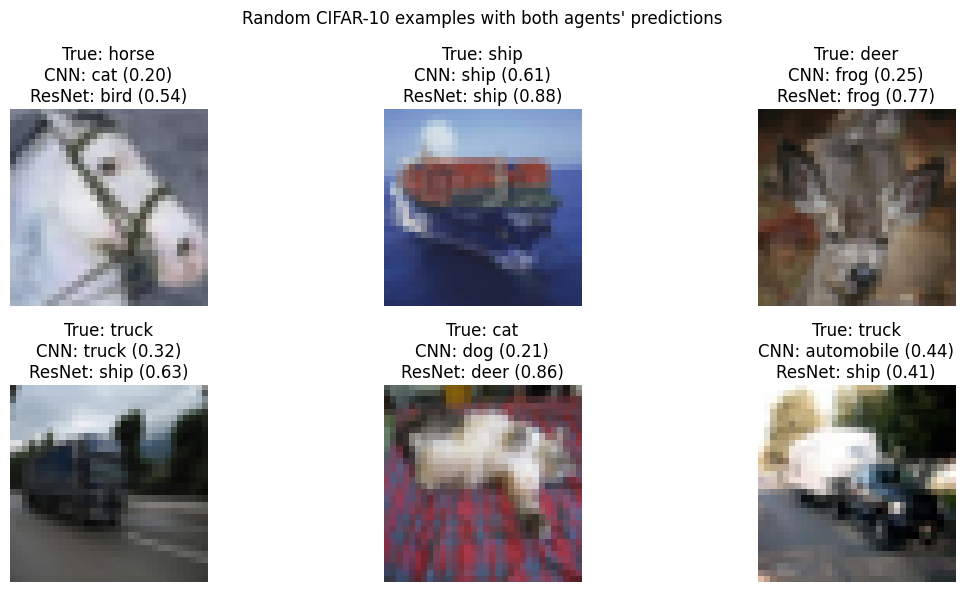

In [11]:
def show_examples(df: pd.DataFrame, title: str, n: int = 6):
    sample = df.sample(n=min(n, len(df)), random_state=SEED)
    plt.figure(figsize=(12, 6))
    for j, row in enumerate(sample.itertuples(index=False), start=1):
        plt.subplot(2, 3, j)
        img = x_test[row.test_idx]
        plt.imshow(img)
        plt.axis("off")
        plt.title(
            f"True: {row.true_name}\n"
            f"CNN: {row.cnn_name} ({row.cnn_conf:.2f})\n"
            f"ResNet: {row.resnet_name} ({row.resnet_conf:.2f})"
        )
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

show_examples(results_df, "Random CIFAR-10 examples with both agents' predictions", n=6)
